# Community Area Feature Visualization Pipeline

Reads `02_merged_data_sample.parquet`, assigns each trip to one of Chicago's 77 **community areas** (via `pickup_community_area` / `dropoff_community_area`), and visualises trip-count and feature distributions per community area.

Community-area boundaries come from `chicago_community_boundaries.json`. All maps are static **matplotlib / geopandas** choropleths drawn side by side: **Pickup (left)** and **Dropoff (right)**. When a section has several options (features, days of week, hours, 8-hour blocks) every option is plotted on its own row, stacked below each other, keeping the pickup/dropoff column layout.

In [ ]:
import pandas as pd
import polars as pl
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize
import geopandas

## Load data

Load only the columns needed for the community-area analysis. `trip_seconds` is stored as a duration, so we convert it to total seconds for aggregation.

In [ ]:
_BASE_COLS = [
    "pickup_community_area", "dropoff_community_area",
    "trip_start", "trip_end", "hour", "day_of_week", "is_weekend",
]
_FEATURE_COLS = [
    "fare_usd", "tips_usd", "tolls_usd", "extras_usd", "trip_total_usd",
    "trip_miles", "trip_seconds", "average_speed_mph",
    "temperature_2m", "apparent_temperature", "temperature_2m_max", "temperature_2m_min",
    "precipitation", "rain", "relative_humidity_2m", "snow_depth",
    "wind_speed_10m", "wind_direction_10m", "wind_gusts_10m",
]

df = (
    pl.read_parquet("../data/02_merged_data_sample.parquet", columns=_BASE_COLS + _FEATURE_COLS)
    .with_columns(pl.col("trip_seconds").dt.total_seconds().alias("trip_seconds"))
    .to_pandas()
)
print(f"Shape: {df.shape[0]:,} rows x {df.shape[1]} columns")
df.head(3)

## Load community-area boundaries

Build a `GeoDataFrame` of the 77 community areas, keyed by `area_number` (matches `pickup_community_area` / `dropoff_community_area` in the trip data).

In [ ]:
communities_gdf = geopandas.read_file("../data/chicago_community_boundaries.json")
communities_gdf["area_number"] = communities_gdf["area_numbe"].astype(int)
communities_gdf["community"] = communities_gdf["community"].str.title()
communities_gdf = communities_gdf[["area_number", "community", "geometry"]].set_crs("EPSG:4326")

print(f"{len(communities_gdf)} community areas loaded")
communities_gdf.head(3)

## Aggregation & plotting helpers

`_community_aggregate` counts trips (or averages a feature) per community area.

`plot_community_grid` draws the choropleths: one **row per option**, **Pickup on the left**, **Dropoff on the right**. Each row may use a different pickup/dropoff subset (useful for hour-of-day, where pickup time and dropoff time differ). With `shared_scale=True` all rows share one colour scale (good for comparing options); with `shared_scale=False` each row gets its own scale and colourbar (good for the feature maps, whose ranges differ).

In [31]:
def _community_aggregate(df_subset, trip_type, feature=None):
    """Aggregate df_subset by community area.
    trip_type is 'pickup' or 'dropoff'.
    Returns [area_number, trip_count] or [area_number, mean_val, trip_count].
    """
    col = f"{trip_type}_community_area"
    sub = df_subset.dropna(subset=[col] + ([feature] if feature else []))
    if feature:
        agg = sub.groupby(col)[feature].agg(["mean", "count"]).reset_index()
        agg.columns = ["area_number", "mean_val", "trip_count"]
    else:
        agg = sub[col].value_counts().reset_index()
        agg.columns = ["area_number", "trip_count"]
    agg["area_number"] = agg["area_number"].astype(int)
    return agg


def _row_geo(sub_pickup, sub_dropoff, kind, feature):
    """Return [pickup_gdf, dropoff_gdf] for one row, with the value column merged on.

    Community areas with no trips are left as NaN (not filled with 0) so they can be
    drawn explicitly in white via missing_kwds, rather than appearing as the pale
    low end of the colour gradient.
    """
    gs = []
    for subset, trip_type in ((sub_pickup, "pickup"), (sub_dropoff, "dropoff")):
        agg = _community_aggregate(subset, trip_type, feature if kind == "mean" else None)
        g = communities_gdf.merge(agg, on="area_number", how="left")
        gs.append(g)
    return gs


def _value_range(gdfs, value_col, force_zero_min):
    vals = np.concatenate([g[value_col].to_numpy(dtype="float64") for g in gdfs])
    vals = vals[~np.isnan(vals)]
    if vals.size == 0:
        return 0.0, 1.0
    lo = 0.0 if force_zero_min else float(vals.min())
    hi = float(vals.max())
    return lo, (hi if hi > lo else lo + 1)


# One consistent gradient for every trip-count map; the feature maps keep their own
# (blue) gradient. Community areas with no trips are always drawn in white.
COUNT_CMAP = "YlOrRd"
FEATURE_CMAP = "PuBuGn"
NO_TRIPS_COLOR = "white"


def plot_community_grid(items, kind="count", cmap=COUNT_CMAP, suptitle="",
                        shared_scale=True, cbar_label=None, row_height=3.8):
    """Plot a stacked grid of Pickup (left) / Dropoff (right) choropleths.

    items: list of (label, sub_pickup, sub_dropoff, feature). For counts pass
           feature=None; sub_pickup/sub_dropoff are usually the same dataframe
           except for hour-of-day, where they are filtered by pickup vs dropoff time.
    kind:  'count' (uses trip_count) or 'mean' (uses mean_val of `feature`).

    Community areas with no trips are rendered in white (NO_TRIPS_COLOR) with a thin
    grey border so empty areas are still visible.
    """
    value_col = "trip_count" if kind == "count" else "mean_val"
    force_zero = kind == "count"

    rows = [(label, _row_geo(sp, sd, kind, feat)) for label, sp, sd, feat in items]

    if shared_scale:
        gvmin, gvmax = _value_range([g for _, gs in rows for g in gs], value_col, force_zero)

    def _label(lbl):
        return cbar_label(lbl) if callable(cbar_label) else cbar_label

    n = len(rows)
    fig, axes = plt.subplots(n, 2, figsize=(11, row_height * n),
                             squeeze=False, constrained_layout=True)

    for i, (label, gs) in enumerate(rows):
        vmin, vmax = (gvmin, gvmax) if shared_scale else _value_range(gs, value_col, force_zero)
        for j, g in enumerate(gs):
            ax = axes[i][j]
            g.plot(column=value_col, ax=ax, cmap=cmap, vmin=vmin, vmax=vmax,
                   edgecolor="0.6", linewidth=0.3,
                   missing_kwds={"color": NO_TRIPS_COLOR, "edgecolor": "0.6",
                                 "linewidth": 0.3, "label": "no trips"})
            side = "Pickup" if j == 0 else "Dropoff"
            ax.set_title(f"{side} — {label}", fontsize=10)
            ax.set_axis_off()
        if not shared_scale:
            sm = ScalarMappable(norm=Normalize(vmin, vmax), cmap=cmap)
            sm.set_array([])
            cb = fig.colorbar(sm, ax=list(axes[i]), fraction=0.046, pad=0.02)
            if cbar_label is not None:
                cb.set_label(_label(label))

    if shared_scale:
        sm = ScalarMappable(norm=Normalize(gvmin, gvmax), cmap=cmap)
        sm.set_array([])
        cb = fig.colorbar(sm, ax=axes.ravel().tolist(), fraction=0.025, pad=0.02)
        if cbar_label is not None:
            cb.set_label(_label(None))

    if suptitle:
        fig.suptitle(suptitle, fontsize=14)
    plt.show()

## Map: trip count per community area

Number of trips per community area, **Pickup (left)** vs **Dropoff (right)**, on a shared colour scale. All trip-count maps in this notebook use the same `YlOrRd` gradient; community areas with **no trips are drawn in white**.

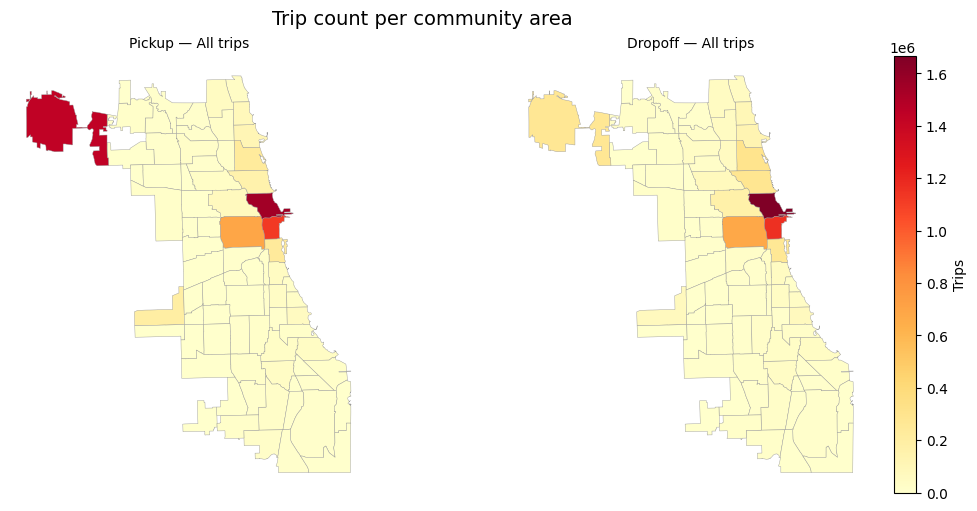

In [32]:
plot_community_grid(
    [("All trips", df, df, None)],
    kind="count", cmap=COUNT_CMAP,
    suptitle="Trip count per community area",
    shared_scale=True, cbar_label="Trips",
    row_height=5.0,
)

## Maps: mean feature value per community area

One row per numeric feature; **Pickup (left)** vs **Dropoff (right)**. The feature maps keep their own blue (`PuBuGn`) gradient, and each feature uses its own colour scale (ranges differ between, e.g., temperature and fare). Community areas with no trips are shown in **white**.

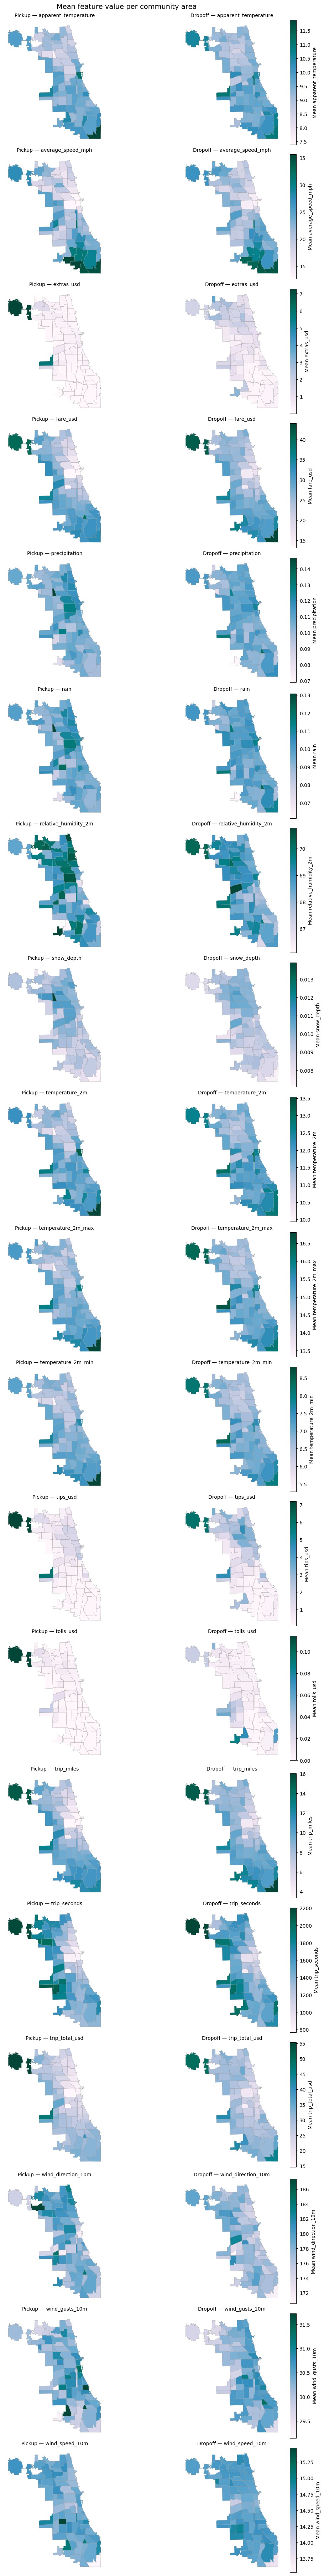

In [33]:
SELECTABLE_FEATURES = [
    "apparent_temperature", "average_speed_mph", "extras_usd", "fare_usd",
    "precipitation", "rain", "relative_humidity_2m", "snow_depth",
    "temperature_2m", "temperature_2m_max", "temperature_2m_min",
    "tips_usd", "tolls_usd", "trip_miles", "trip_seconds", "trip_total_usd",
    "wind_direction_10m", "wind_gusts_10m", "wind_speed_10m",
]
SELECTABLE_FEATURES = [f for f in SELECTABLE_FEATURES if f in df.columns]

plot_community_grid(
    [(feat, df, df, feat) for feat in SELECTABLE_FEATURES],
    kind="mean", cmap=FEATURE_CMAP,
    suptitle="Mean feature value per community area",
    shared_scale=False,
    cbar_label=lambda feat: f"Mean {feat}",
)

## Maps: trips per community area by day of week

One row per weekday; **Pickup (left)** vs **Dropoff (right)**. All days share a colour scale so volumes are comparable across days. `day_of_week` encodes 1 = Monday … 7 = Sunday.

In [34]:
_DOW_NAMES = {
    1: "Monday", 2: "Tuesday", 3: "Wednesday", 4: "Thursday",
    5: "Friday", 6: "Saturday", 7: "Sunday",
}

_dow_items = [
    (name, df[df["day_of_week"] == i], df[df["day_of_week"] == i], None)
    for i, name in _DOW_NAMES.items()
]

plot_community_grid(
    _dow_items,
    kind="count", cmap=COUNT_CMAP,
    suptitle="Trips per community area by day of week",
    shared_scale=True, cbar_label="Trips",
)

MemoryError: Unable to allocate 31.4 MiB for an array with shape (11, 748369) and data type float32

## Maps: trips per community area by hour of day

One row per hour (00–23); **Pickup (left)** vs **Dropoff (right)**. Pickup maps are filtered by pickup hour, dropoff maps by dropoff hour. All hours share a colour scale.

In [ ]:
_dropoff_hour = df["trip_end"].dt.hour

_hour_items = [
    (f"{h:02d}:00", df[df["hour"] == h], df[_dropoff_hour == h], None)
    for h in range(24)
]

plot_community_grid(
    _hour_items,
    kind="count", cmap=COUNT_CMAP,
    suptitle="Trips per community area by hour of day",
    shared_scale=True, cbar_label="Trips",
    row_height=3.4,
)

## Maps: trips per community area by 8-hour block

One row per 8-hour block (00–07, 08–15, 16–23); **Pickup (left)** vs **Dropoff (right)**. Pickup maps use pickup time, dropoff maps use dropoff time. Blocks share a colour scale.

In [ ]:
_pickup_block = df["hour"] // 8
_dropoff_block = df["trip_end"].dt.hour // 8
_BLOCK_LABELS = {0: "00:00–07:59", 1: "08:00–15:59", 2: "16:00–23:59"}

_block_items = [
    (label, df[_pickup_block == b], df[_dropoff_block == b], None)
    for b, label in _BLOCK_LABELS.items()
]

plot_community_grid(
    _block_items,
    kind="count", cmap=COUNT_CMAP,
    suptitle="Trips per community area by 8-hour block",
    shared_scale=True, cbar_label="Trips",
    row_height=4.2,
)

## Maps: trips per community area by month

One row per month present in the data; **Pickup (left)** vs **Dropoff (right)**. Pickup maps are filtered by pickup month (`trip_start`), dropoff maps by dropoff month (`trip_end`). All months share the same `YlOrRd` colour scale so volumes are comparable across months; community areas with no trips are drawn in white.

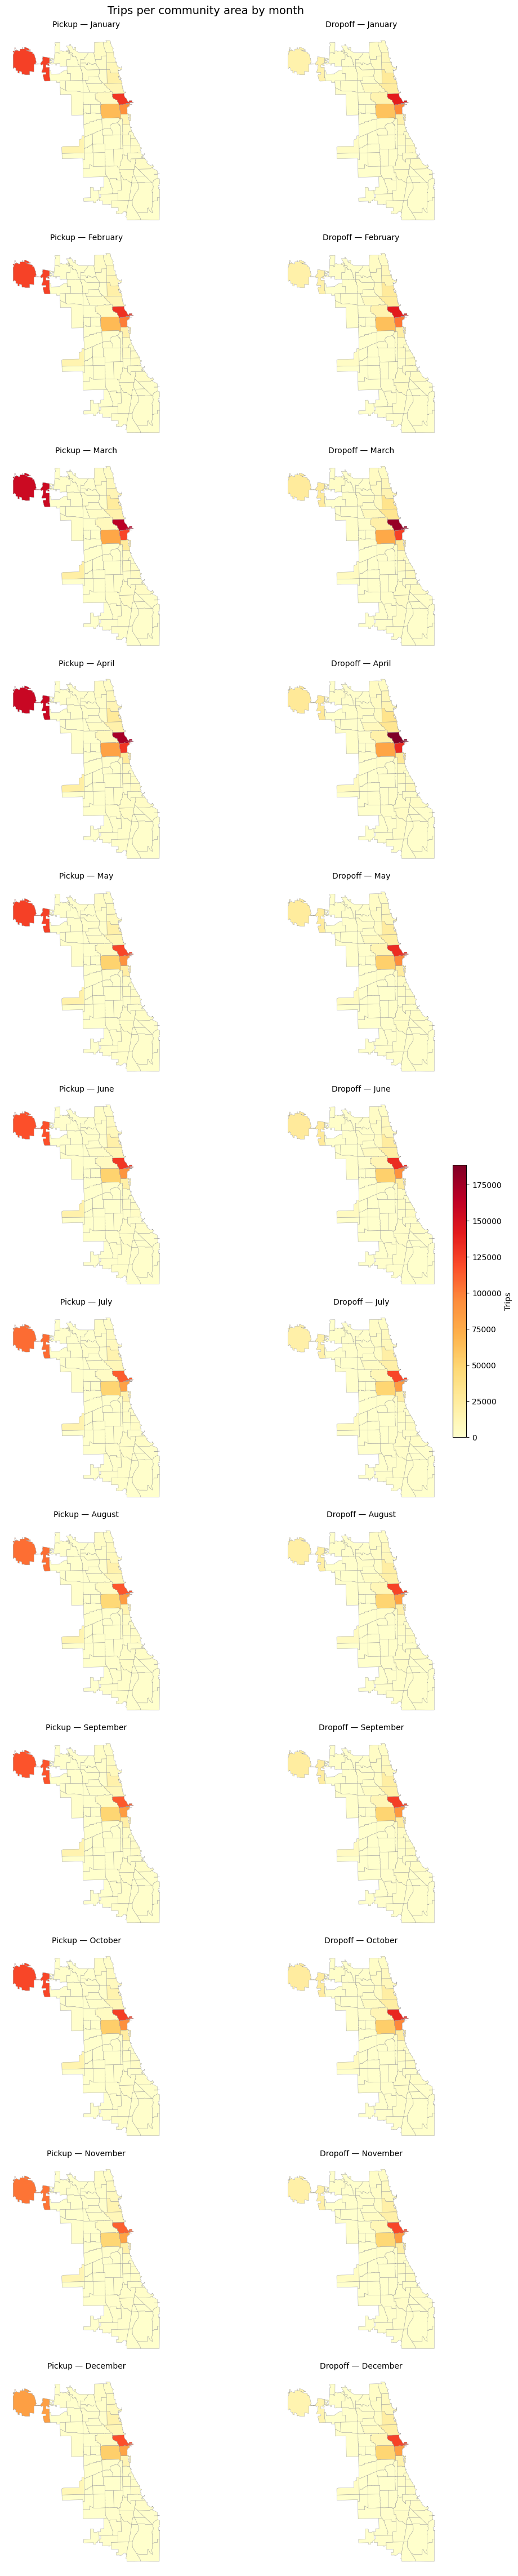

In [35]:
import calendar

_pickup_month = df["trip_start"].dt.month
_dropoff_month = df["trip_end"].dt.month
_months = sorted(_pickup_month.dropna().unique())

_month_items = [
    (calendar.month_name[int(m)], df[_pickup_month == m], df[_dropoff_month == m], None)
    for m in _months
]

plot_community_grid(
    _month_items,
    kind="count", cmap=COUNT_CMAP,
    suptitle="Trips per community area by month",
    shared_scale=True, cbar_label="Trips",
)